# Claude Haiku 4.5 vs Haiku 5.5: same job, a fraction of the price?

A short companion to `02_benchmark.ipynb`. Same 1,000 customer-service conversations, same seven questions, same prompt, same structured output, one call per conversation. The only thing that changes is the model.

**Where the data comes from:** `results/test_predictions.csv` and `results/test_calls.csv`, exported by `02_benchmark.ipynb` from calls that match its configuration fingerprint. Nothing here calls an API.

**Sections:** 1 Load, 2 Cost, 3 Accuracy, 4 Paired differences, 5 Precision and recall, 6 Latency, Caveats.

## 1. Load

In [1]:
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

SEED = 42
OLD, NEW = "Claude Haiku 4.5", "Claude Haiku 5.5"
HAIKUS = [OLD, NEW]
RESULTS_DIR = Path("results")

predictions = pd.read_csv(RESULTS_DIR / "test_predictions.csv", dtype=str, keep_default_na=False)
predictions = predictions[predictions["model"].isin(HAIKUS)]
calls = pd.read_csv(RESULTS_DIR / "test_calls.csv", keep_default_na=False)
calls = calls[calls["model"].isin(HAIKUS)]

QUESTION_TITLES = {
    "reason": "Reason for contact (10 options)", "intent": "Specific intent (55 options)",
    "resolution": "How far the agent went (3 levels)", "identity_verified": "Identity verified?",
    "refund_offered": "Refund issued?", "promo_given": "Promo code given?", "handed_off": "Handed to another team?",
}
YES_NO = ["identity_verified", "refund_offered", "promo_given", "handed_off"]

# One frame per model and question, rows in the same conversation order for both models
def answers(model, question):
    rows = predictions[(predictions["model"] == model) & (predictions["question"] == question)].sort_values("convo_id", key=lambda c: c.astype(int))
    return rows["truth"].values, rows["prediction"].values

for question in QUESTION_TITLES:
    assert (answers(OLD, question)[0] == answers(NEW, question)[0]).all(), "both models must be scored on the same truth"
print({model: int((calls["model"] == model).sum()) for model in HAIKUS}, "calls;", predictions["convo_id"].nunique(), "conversations")

{'Claude Haiku 4.5': 1000, 'Claude Haiku 5.5': 1000} calls; 1000 conversations


## 2. Cost

The headline. Cost per conversation comes from the logged token counts at each model's list price (Haiku 4.5: $1 input / $0.10 cache read / $1.25 cache write / $5 output; Haiku 5.5: $0.10 / $0.01 / $0.125 / $0.50 per million tokens, its rate for prompts up to 100k tokens).

In [2]:
PRICES = {OLD: {"input": 1.00, "cached_input": 0.10, "cache_write": 1.25, "output": 5.00},
          NEW: {"input": 0.10, "cached_input": 0.01, "cache_write": 0.125, "output": 0.50}}
TOKEN_COLUMNS = {"input": "uncached_input_tokens", "cache_write": "cache_write_tokens", "cached_input": "cached_input_tokens", "output": "output_tokens"}

cost_rows = {}
for model in HAIKUS:
    model_calls = calls[calls["model"] == model]
    parts = {part: model_calls[column].sum() * PRICES[model][part] / 1e6 / len(model_calls) * 1000 for part, column in TOKEN_COLUMNS.items()}
    cost_rows[model] = {
        **{f"{part} $ / 1,000": value for part, value in parts.items()},
        "total $ / 1,000 conversations": sum(parts.values()),
        "input tokens / call": model_calls[["uncached_input_tokens", "cache_write_tokens", "cached_input_tokens"]].sum(axis=1).mean(),
        "cache hit share": model_calls["cached_input_tokens"].sum() / model_calls[["uncached_input_tokens", "cache_write_tokens", "cached_input_tokens"]].sum().sum(),
        "output tokens / call": model_calls["output_tokens"].mean(),
    }
cost_table = pd.DataFrame(cost_rows).T
cost_table["$ / month at 10M conversations"] = cost_table["total $ / 1,000 conversations"] * 10_000
ratio = cost_table.loc[OLD, "total $ / 1,000 conversations"] / cost_table.loc[NEW, "total $ / 1,000 conversations"]
print(f"Haiku 5.5 costs 1/{ratio:.0f} of Haiku 4.5 on this workload")
cost_table.round(4)

Haiku 5.5 costs 1/20 of Haiku 4.5 on this workload


,"input $ / 1,000","cache_write $ / 1,000","cached_input $ / 1,000","output $ / 1,000","total $ / 1,000 conversations",input tokens / call,cache hit share,output tokens / call,$ / month at 10M conversations
Claude Haiku 4.5,2.5413,0.0,0.0000,0.2900,2.8313,2541.282,0.0000,58.004,28313.020
Claude Haiku 5.5,0.0354,0.0,0.0295,0.0791,0.1441,3301.366,0.8927,158.287,1440.501


**Where the 20x comes from.** About 10x is the price list. The rest is caching: the ~2,900-token question block is identical on every call. Haiku 5.5 caches it and reads it back at a tenth of the input price. Haiku 4.5 can't, because its minimum cacheable prompt is 4,096 tokens. Two things push the other way and are already in the number: Haiku 5.5's newer tokenizer counts about 30% more tokens for the same text, and it thinks by default, so it writes roughly 2.7x as many output tokens.

## 3. Accuracy, question by question

In [3]:
BOOTSTRAP = np.random.default_rng(SEED).integers(0, 1000, size=(2000, 1000))   # same resamples as 02_benchmark

def correct(model, question):
    truth, predicted = answers(model, question)
    return truth == predicted

def flags(model, question):
    truth, predicted = answers(model, question)
    return truth == "True", predicted == "True"

def f2_from(truth, predicted):
    tp = np.sum(truth & predicted, axis=-1)
    return 5 * tp / np.maximum(5 * tp + 4 * np.sum(truth & ~predicted, axis=-1) + np.sum(~truth & predicted, axis=-1), 1)

def headline(model, question, index=None):
    # Accuracy for choice and level questions, F2 for yes/no, optionally on bootstrap resamples
    if question in YES_NO:
        truth, predicted = flags(model, question)
        return f2_from(truth, predicted) if index is None else f2_from(truth[index], predicted[index])
    hits = correct(model, question)
    return hits.mean() if index is None else hits[index].mean(axis=-1)

score_rows = []
for question in QUESTION_TITLES:
    for model in HAIKUS:
        low, high = np.percentile(headline(model, question, BOOTSTRAP), [2.5, 97.5])
        score_rows.append({"question": question, "model": model, "metric": "F2" if question in YES_NO else "accuracy",
                           "score": headline(model, question), "low": low, "high": high})
scores = pd.DataFrame(score_rows)
scores.pivot(index="question", columns="model", values="score").round(3)

model,Claude Haiku 4.5,Claude Haiku 5.5
question,,
handed_off,0.934,0.976
identity_verified,0.815,0.803
intent,0.761,0.771
promo_given,0.985,1.000
reason,0.842,0.852
refund_offered,0.856,0.845
resolution,0.889,0.916


## 4. Paired differences: is Haiku 5.5 really "the same"?

Haiku 5.5 minus Haiku 4.5 on the same conversations (accuracy points, or F2 points x 100), tested with the same **paired permutation test** as `02_benchmark.ipynb`: if the two were equally good, each conversation's pair of answers could be swapped between them without changing anything, so the p-value is the share of random swaps that open a gap at least as large as the one observed. Only conversations where the two answers differ can move the gap; with 16 or fewer, every swap pattern is enumerated (an exact test), otherwise 200,000 random swaps.

Seven comparisons, so a verdict needs p below 0.05 / 7 = 0.0071 (Bonferroni). A raw p under 0.05 that misses that bar is *suggestive*; anything else means this test set can't tell the two apart, which is not the same as proving them equal.

The first version of this notebook used percentile bootstrap intervals and called Haiku 5.5 better on promo codes and handoffs. On those two questions only 4 and 5 conversations get different answers, nearly all in 5.5's favour, and resampling can't produce the reverse, so the interval excluded zero however few cases there were. The exact test gives p = 0.125 for both.

In [4]:
import itertools

PERMUTATION_DRAWS = 200_000
EXACT_UP_TO = 16   # enumerate every swap pattern when this few conversations differ
ALPHA = 0.05 / len(QUESTION_TITLES)   # Bonferroni over the seven questions

def headline_counts(model, question):
    # Per-conversation contributions to the headline metric: correctness for accuracy, (TP, FP, FN) for F2
    if question in YES_NO:
        truth, predicted = flags(model, question)
        return np.stack([truth & predicted, ~truth & predicted, truth & ~predicted], axis=1).astype(float)
    return correct(model, question).astype(float)[:, None]

def metric_from_counts(question, totals, n):
    if question in YES_NO:
        return 5 * totals[..., 0] / np.maximum(5 * totals[..., 0] + 4 * totals[..., 2] + totals[..., 1], 1)
    return totals[..., 0] / n

def paired_permutation(question, rng):
    # Two-sided: how often swapping each conversation's two answers at random opens a gap at least as large as observed.
    # Swapping conversation i moves (old_i - new_i) into Haiku 5.5's totals and out of 4.5's.
    counts_new, counts_old = headline_counts(NEW, question), headline_counts(OLD, question)
    n = len(counts_new)
    totals_new, totals_old = counts_new.sum(axis=0), counts_old.sum(axis=0)
    observed = metric_from_counts(question, totals_new, n) - metric_from_counts(question, totals_old, n)
    differing = np.flatnonzero(answers(NEW, question)[1] != answers(OLD, question)[1])
    if len(differing) == 0:
        return observed, 0, 1.0
    delta = counts_old[differing] - counts_new[differing]
    exact = len(differing) <= EXACT_UP_TO
    patterns = np.array(list(itertools.product([0.0, 1.0], repeat=len(differing)))) if exact else None
    total_draws = len(patterns) if exact else PERMUTATION_DRAWS
    hits = 0
    for start in range(0, total_draws, 20_000):
        size = min(20_000, total_draws - start)
        swaps = patterns[start:start + size] if exact else (rng.random((size, len(differing))) < 0.5).astype(float)
        moved = swaps @ delta
        gaps = metric_from_counts(question, totals_new + moved, n) - metric_from_counts(question, totals_old - moved, n)
        hits += int(np.sum(np.abs(gaps) >= abs(observed) - 1e-12))
    p = hits / total_draws if exact else (hits + 1) / (total_draws + 1)   # Monte Carlo: never report exactly 0
    return observed, len(differing), p

permutation_rng = np.random.default_rng(SEED)
difference_rows = []
for question in QUESTION_TITLES:
    point, differing, p = paired_permutation(question, permutation_rng)
    verdict = (("5.5 better" if point > 0 else "4.5 better") if p < ALPHA
               else "suggestive only" if p < 0.05 else "can't tell apart")
    difference_rows.append({"question": question, "Haiku 5.5 minus 4.5": point * 100, "answers that differ": differing,
                            "p": p, "verdict": verdict})
differences = pd.DataFrame(difference_rows).set_index("question")
differences.round({"Haiku 5.5 minus 4.5": 1, "p": 4})

,Haiku 5.5 minus 4.5,answers that differ,p,verdict
question,,,,
reason,1.0,122,0.3780,can't tell apart
intent,1.0,161,0.3774,can't tell apart
resolution,2.7,41,0.0000,5.5 better
identity_verified,-1.2,53,0.0040,4.5 better
refund_offered,-1.1,11,0.5801,can't tell apart
promo_given,1.5,4,0.1250,can't tell apart
handed_off,4.2,5,0.1250,can't tell apart


## 5. Precision and recall

Same framing as the main notebook: for a compliance audit of identity checks, a false "verified" hides the very calls being looked for, so precision matters; for refunds, promos and handoffs, a miss is the expensive mistake, so recall matters.

In [5]:
pr_rows = []
for question in YES_NO:
    for model in HAIKUS:
        truth, predicted = flags(model, question)
        tp = np.sum(truth & predicted)
        pr_rows.append({"question": question, "model": model, "precision": tp / max(predicted.sum(), 1),
                        "recall": tp / max(truth.sum(), 1), "false alarms": int(np.sum(predicted & ~truth)),
                        "misses": int(np.sum(~predicted & truth))})
precision_recall = pd.DataFrame(pr_rows)
precision_recall.set_index(["question", "model"]).round(3)

precision  recall  false alarms  misses
question          model                                                    
identity_verified Claude Haiku 4.5      0.474   0.994           378       2
                  Claude Haiku 5.5      0.462   0.985           394       5
refund_offered    Claude Haiku 4.5      0.656   0.926            33       5
                  Claude Haiku 5.5      0.685   0.897            28       7
promo_given       Claude Haiku 4.5      0.929   1.000             4       0
                  Claude Haiku 5.5      1.000   1.000             0       0
handed_off        Claude Haiku 4.5      0.895   0.944             8       4
                  Claude Haiku 5.5      0.889   1.000             9       0

## 6. Latency

In [6]:
latency = calls.groupby("model")["latency_s"].describe(percentiles=[0.5, 0.9, 0.99])[["50%", "90%", "99%", "max"]]
latency.round(2)

,50%,90%,99%,max
model,,,,
Claude Haiku 4.5,1.29,1.62,2.54,7.92
Claude Haiku 5.5,1.23,2.07,3.07,3.69


## Figures

Video-ready PNGs in `figures/haiku/`, in the same style and colours as the main benchmark: Haiku 4.5 orange, Haiku 5.5 green (a pair the palette validator passes for colour-blind separation). Every mark carries its value.

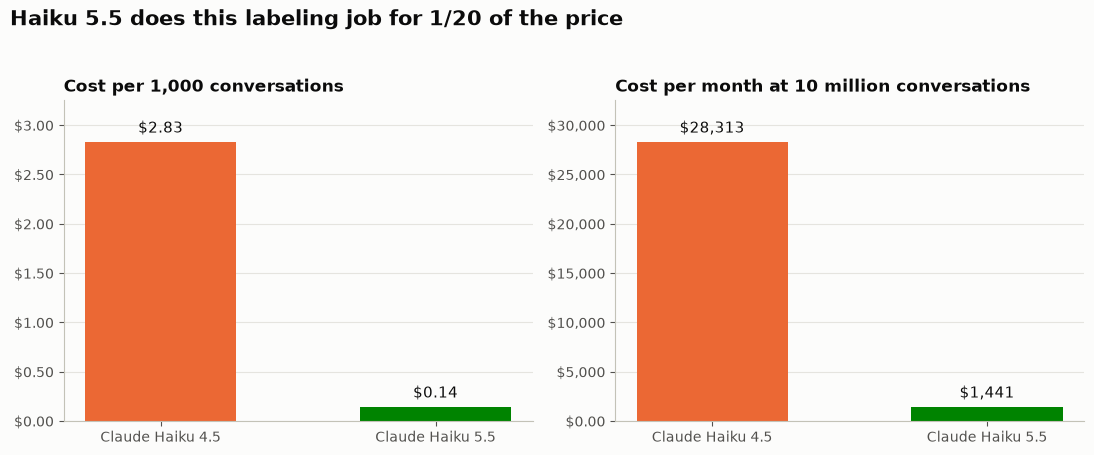

saved figures\haiku\h1_cost.png


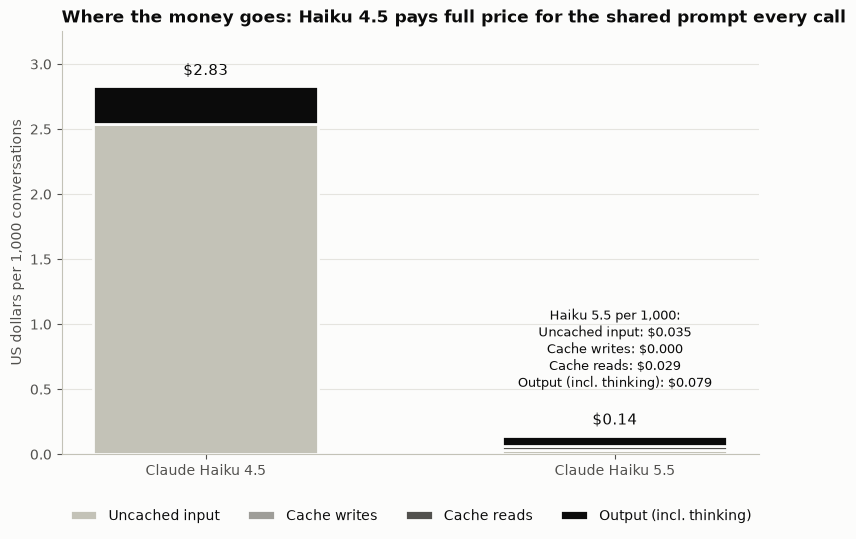

saved figures\haiku\h2_cost_breakdown.png


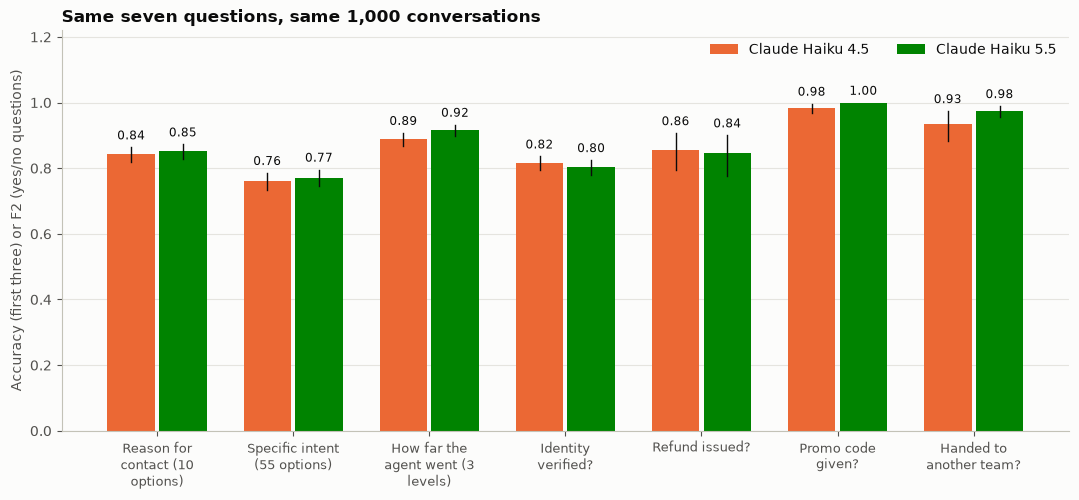

saved figures\haiku\h3_scores.png


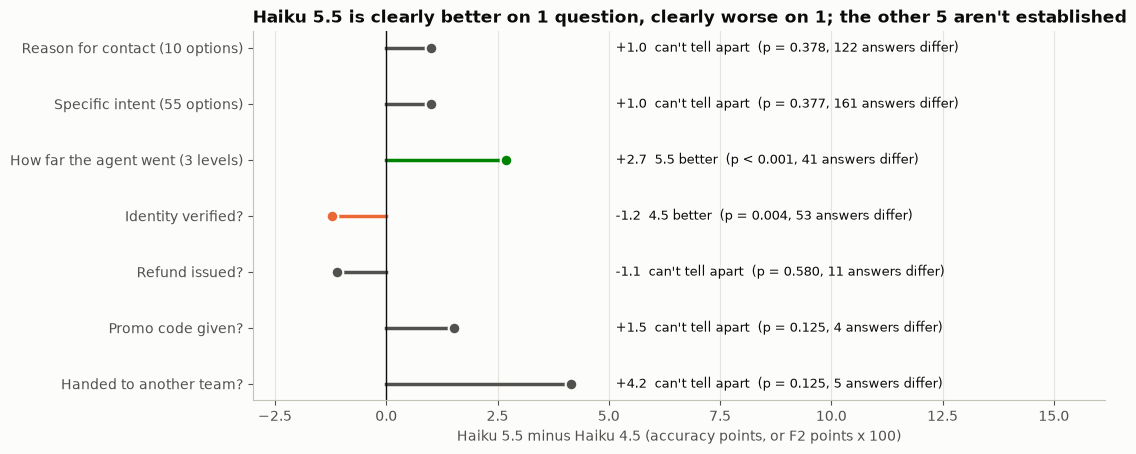

saved figures\haiku\h4_paired_differences.png


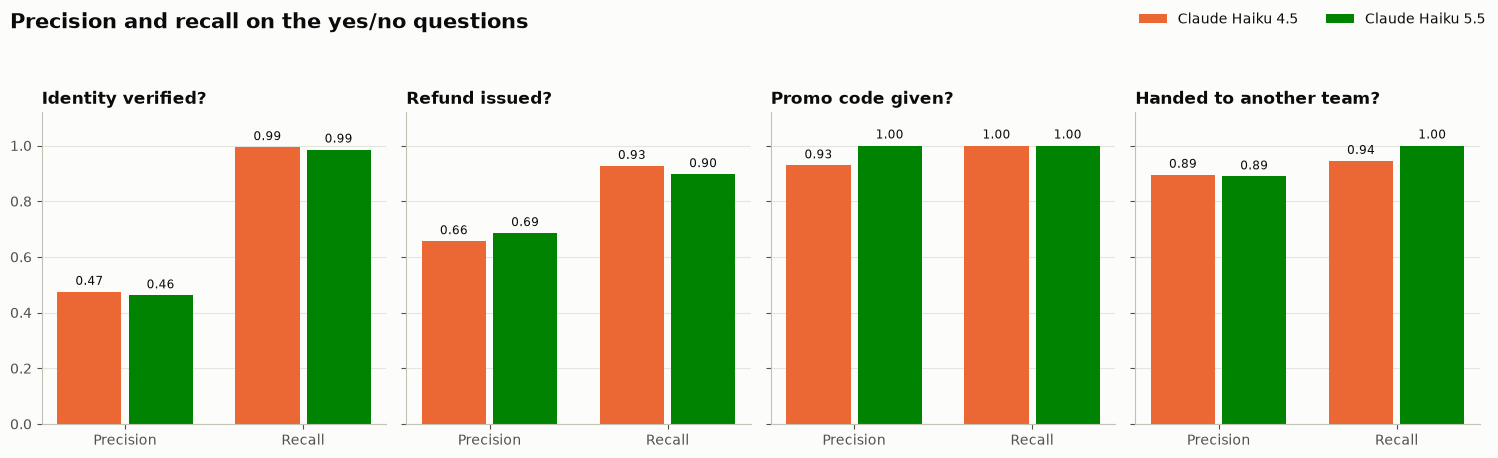

saved figures\haiku\h5_precision_recall.png


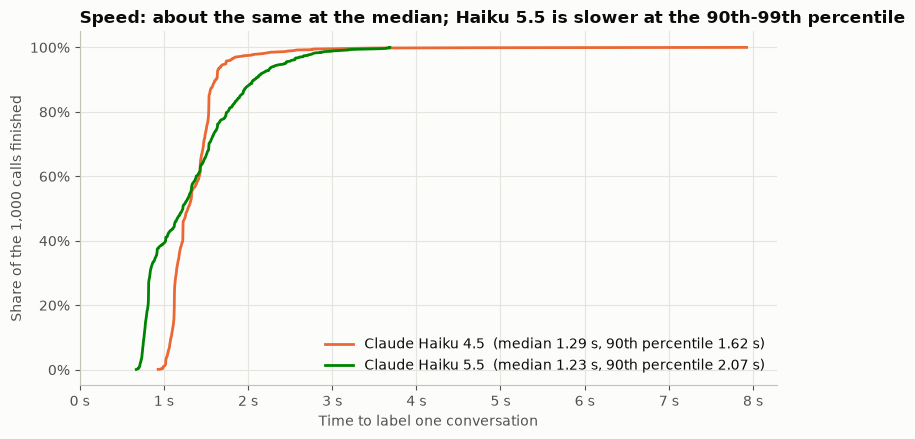

saved figures\haiku\h6_latency.png


In [7]:
import time

FIGURES_DIR = Path("figures") / "haiku"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
INK, MUTED_INK, AXIS, GRID, SURFACE = "#0b0b0b", "#52514e", "#c3c2b7", "#e5e4df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": MUTED_INK, "xtick.color": MUTED_INK, "ytick.color": MUTED_INK,
    "text.color": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "legend.frameon": False,
})
COLORS = {OLD: "#eb6834", NEW: "#008300"}

def style_value_axis(ax, axis="y"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    for attempt in range(5):   # Windows: a file watcher can hold a just-written PNG for a moment (OSError 22)
        try:
            fig.savefig(path, dpi=200, bbox_inches="tight")
            break
        except OSError:
            if attempt == 4:
                raise
            time.sleep(0.5)
    plt.show()
    print(f"saved {path}")

# h1. The headline: cost per 1,000 conversations and per month at 10M
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, column, title, fmt in [(axes[0], "total $ / 1,000 conversations", "Cost per 1,000 conversations", lambda v: f"${v:,.2f}"),
                               (axes[1], "$ / month at 10M conversations", "Cost per month at 10 million conversations", lambda v: f"${v:,.0f}")]:
    values = cost_table.loc[HAIKUS, column]
    ax.bar(range(2), values.values, width=0.55, color=[COLORS[model] for model in HAIKUS])
    for x, value in enumerate(values.values):
        ax.text(x, value + values.max() * 0.02, fmt(value), ha="center", va="bottom", fontsize=11, color=INK)
    ax.set_xticks(range(2), HAIKUS)
    ax.set_ylim(0, values.max() * 1.15)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}" if v >= 10 else f"${v:,.2f}"))
    style_value_axis(ax)
fig.suptitle(f"Haiku 5.5 does this labeling job for 1/{ratio:.0f} of the price", x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_figure(fig, "h1_cost")

# h2. Where the money goes: cost per 1,000 conversations split by token type (one hue, light to dark)
PARTS = {"input": "Uncached input", "cache_write": "Cache writes", "cached_input": "Cache reads", "output": "Output (incl. thinking)"}
PART_COLORS = ["#c3c2b7", "#9e9d98", "#52514e", "#0b0b0b"]
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(2)
for (part, label), color in zip(PARTS.items(), PART_COLORS):
    values = cost_table.loc[HAIKUS, f"{part} $ / 1,000"].values
    ax.bar(range(2), values, bottom=bottom, width=0.55, color=color, label=label, edgecolor=SURFACE, linewidth=2)
    bottom += values
for x, total in enumerate(bottom):
    ax.text(x, total + bottom.max() * 0.02, f"${total:,.2f}", ha="center", va="bottom", fontsize=11, color=INK)
# Haiku 5.5's column is too thin to read its parts, so spell them out beside it
new_parts = [f"{label}: ${cost_table.loc[NEW, f'{part} $ / 1,000']:.3f}" for part, label in PARTS.items()]
ax.text(1, bottom[1] + bottom.max() * 0.12, "\n".join(["Haiku 5.5 per 1,000:"] + new_parts), ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_xticks(range(2), HAIKUS)
ax.set_ylabel("US dollars per 1,000 conversations")
ax.set_ylim(0, bottom.max() * 1.15)
fig.set_size_inches(9, 5.5)
ax.set_title("Where the money goes: Haiku 4.5 pays full price for the shared prompt every call")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
style_value_axis(ax)
save_figure(fig, "h2_cost_breakdown")

# h3. Accuracy / F2 per question, side by side, with 95% intervals
fig, ax = plt.subplots(figsize=(13, 5.2))
questions = list(QUESTION_TITLES)
width = 0.38
for offset, model in zip([-width / 2, width / 2], HAIKUS):
    rows = scores[scores["model"] == model].set_index("question").loc[questions]
    xs = np.arange(len(questions)) + offset
    ax.bar(xs, rows["score"], width=width * 0.92, color=COLORS[model], label=model)
    for x, (score, low, high) in zip(xs, rows[["score", "low", "high"]].values):
        ax.plot([x, x], [low, high], color=INK, linewidth=1)
        ax.text(x, high + 0.015, f"{score:.2f}", ha="center", va="bottom", fontsize=8.5, color=INK)
ax.set_xticks(range(len(questions)), [textwrap.fill(QUESTION_TITLES[q], 16, break_long_words=False) for q in questions], fontsize=9)
ax.set_ylim(0, 1.22)
ax.set_ylabel("Accuracy (first three) or F2 (yes/no questions)")
ax.set_title("Same seven questions, same 1,000 conversations")
ax.legend(loc="upper right", ncol=2)
style_value_axis(ax)
save_figure(fig, "h3_scores")

# h4. Paired differences: bar = observed gap, colour = verdict from the paired permutation test (grey = not established)
fig, ax = plt.subplots(figsize=(11, 4.8))
ordered = differences.loc[questions[::-1]]
VERDICT_COLORS = {"5.5 better": COLORS[NEW], "4.5 better": COLORS[OLD]}
for y, (question, row) in enumerate(ordered.iterrows()):
    color = VERDICT_COLORS.get(row["verdict"], MUTED_INK)
    gap = row["Haiku 5.5 minus 4.5"]
    ax.plot([0, gap], [y, y], color=color, linewidth=2.5)
    ax.scatter(gap, y, s=70, color=color, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    p_text = "p < 0.001" if row["p"] < 0.001 else f"p = {row['p']:.3f}"
    ax.text(ordered["Haiku 5.5 minus 4.5"].max() + 1, y, f"{gap:+.1f}  {row['verdict']}  ({p_text}, {row['answers that differ']} answers differ)",
            va="center", fontsize=9, color=INK)
ax.axvline(0, color=INK, linewidth=1)
ax.set_yticks(range(len(ordered)), [QUESTION_TITLES[q] for q in ordered.index])
ax.set_xlabel("Haiku 5.5 minus Haiku 4.5 (accuracy points, or F2 points x 100)")
ax.set_xlim(min(-3, ordered["Haiku 5.5 minus 4.5"].min() - 1), ordered["Haiku 5.5 minus 4.5"].max() + 12)
better, worse = int((differences["verdict"] == "5.5 better").sum()), int((differences["verdict"] == "4.5 better").sum())
ax.set_title(f"Haiku 5.5 is clearly better on {better} question{'s' * (better != 1)}, clearly worse on {worse}; "
             f"the other {len(differences) - better - worse} aren't established")
style_value_axis(ax, "x")
save_figure(fig, "h4_paired_differences")

# h5. Precision and recall on the four yes/no questions
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6), sharey=True)
for ax, question in zip(axes, YES_NO):
    rows = precision_recall[precision_recall["question"] == question].set_index("model")
    for group, metric in enumerate(["precision", "recall"]):
        for offset, model in zip([-0.2, 0.2], HAIKUS):
            value = rows.loc[model, metric]
            ax.bar(group + offset, value, width=0.36, color=COLORS[model], label=model if (group, question) == (0, YES_NO[0]) else None)
            ax.text(group + offset, value + 0.015, f"{value:.2f}", ha="center", va="bottom", fontsize=8.5, color=INK)
    ax.set_xticks([0, 1], ["Precision", "Recall"])
    ax.set_ylim(0, 1.12)
    ax.set_title(QUESTION_TITLES[question])
    style_value_axis(ax)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, fontsize=10)
fig.suptitle("Precision and recall on the yes/no questions", x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
save_figure(fig, "h5_precision_recall")

# h6. Latency: every call
fig, ax = plt.subplots(figsize=(9, 4.6))
for model in HAIKUS:
    values = np.sort(calls.loc[calls["model"] == model, "latency_s"].values)
    ax.plot(values, np.arange(1, len(values) + 1) / len(values), color=COLORS[model], linewidth=2,
            label=f"{model}  (median {np.median(values):.2f} s, 90th percentile {np.quantile(values, 0.9):.2f} s)")
ax.set_xlim(0, None)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g} s"))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Time to label one conversation")
ax.set_ylabel("Share of the 1,000 calls finished")
ax.set_title("Speed: about the same at the median; Haiku 5.5 is slower at the 90th-99th percentile")
ax.legend(loc="lower right")
ax.grid(color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
save_figure(fig, "h6_latency")

## Caveats

- **Not "the same quality".** The cost is 1/20; the quality is better on one question, worse on one, and not established either way on the other five. Whether that trade is "the same" depends on which question matters to you.
- **One workload.** Short (~250-token) conversations, seven questions, a ~2,900-token shared question block. The 20x depends on that shape: about 10x is list price, the rest is caching that Haiku 4.5 can't use below 4,096 tokens. A workload with long unique inputs and no shared prefix would see closer to 10x.
- **Haiku 5.5 thinks by default** (adaptive, effort medium) and Haiku 4.5 doesn't. Both ran at their provider default; neither was tuned. Anthropic's usage doesn't split thinking tokens out, so the extra output is inferred from the totals.
- **The newer tokenizer** counts about 30% more tokens for the same text; that is already inside Haiku 5.5's cost.
- **Prices are list prices** checked on 2026-10-08 (Haiku 5.5's rate for prompts up to 100k tokens), applied to logged token counts; not invoices.
- **Role-played data and system-event labels**, as in the main notebook. The identity question in particular measures how the question was worded as much as the model (both Haikus flag ~380-390 false "verified").
- **1,000 conversations, seven tests.** Verdicts come from paired permutation tests with a Bonferroni correction for the seven questions. On promo codes and handoffs only 4 and 5 conversations get different answers, so Haiku 5.5's lead there (no false promo codes, no missed handoffs) can't be separated from chance (p = 0.125 for both). A difference that isn't established is not proof the two are equal.